[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ahmed-Bayoumy/MECH559/blob/colab-version/L04/L04_polynomial_regression.ipynb)

# Polynomial Regression: Normal Equations, Ill-Conditioning, and Ridge
### MECH 559 - Systems Optimization - L04
### Course Instructor: Dr. Ahmed Bayoumy
Author of the notebook: Dr. Ahmed Bayoumy

This notebook fits polynomial surrogates by directly solving the normal
equations, then deliberately breaks them (an ill-conditioned design matrix)
and fixes the problem two ways: ridge regularization and variable scaling.

## Learning objectives

By the end, you should be able to:

1. Solve the least-squares normal equations $\mathbf w=(\mathbf Z^\mathsf T\mathbf Z)^{-1}\mathbf Z^\mathsf T\mathbf y$ from scratch and confirm it against `numpy.linalg.lstsq`.
2. Explain *why* $\mathbf Z^\mathsf T\mathbf Z$ becomes ill-conditioned (collinear/badly scaled columns) and observe the resulting instability.
3. Derive and implement ridge regression, and see $\lambda$ trade bias for numerical stability.
4. Show that scaling $\mathbf x$ to $[0,1]$ is a free fix for conditioning.

> **Classroom rhythm:** I will pause at each **Predict** prompt before running the next cell.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

try:
    import ipywidgets as widgets
    from IPython.display import display
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False

rng = np.random.default_rng(559)
plt.rcParams.update({"font.size": 11, "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25})
COLORS = {"data": "#264653", "fit": "#00798C", "perturbed": "#D1495B", "ridge": "#2A9D8F", "test": "#EDAE49"}
print(f"Optional widgets available: {WIDGETS_AVAILABLE}")

Optional widgets available: True


---
## 1. The normal equations, from scratch

We fit a degree-2 polynomial $\hat y = w_0 + w_1 x + w_2 x^2$ to noisy data by
building the design matrix $\mathbf Z$ and solving
$\mathbf w = (\mathbf Z^\mathsf T\mathbf Z)^{-1}\mathbf Z^\mathsf T\mathbf y$ directly -- exactly
the closed-form result derived on the slides.

normal-equations solution: [ 0.9662 -1.9763  3.0619]
numpy lstsq solution:      [ 0.9662 -1.9763  3.0619]


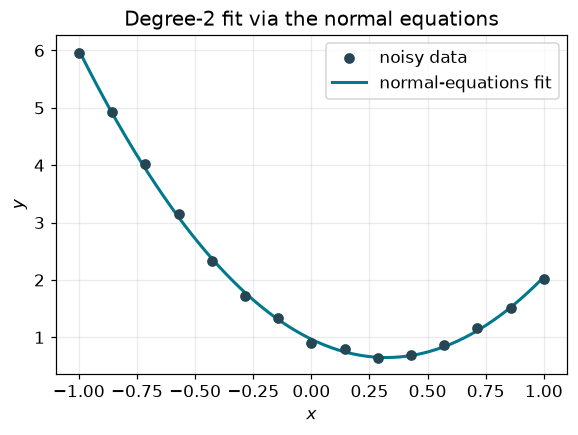

In [3]:
def design_matrix(x, degree):
    return np.column_stack([x**power for power in range(degree + 1)])


def normal_equations_fit(x, y, degree):
    Z = design_matrix(x, degree)
    w = np.linalg.inv(Z.T @ Z) @ Z.T @ y
    return w


true_w = np.array([1.0, -2.0, 3.0])
x_data = np.linspace(-1, 1, 15)
y_data = design_matrix(x_data, 2) @ true_w + rng.normal(scale=0.05, size=x_data.size)

w_manual = normal_equations_fit(x_data, y_data, degree=2)
w_lstsq, *_ = np.linalg.lstsq(design_matrix(x_data, 2), y_data, rcond=None)
print("normal-equations solution:", np.round(w_manual, 4))
print("numpy lstsq solution:     ", np.round(w_lstsq, 4))
assert np.allclose(w_manual, w_lstsq, atol=1e-8)

x_dense = np.linspace(-1, 1, 200)
fig, ax = plt.subplots(figsize=(6, 4))
ax.scatter(x_data, y_data, color=COLORS["data"], label="noisy data", zorder=3)
ax.plot(x_dense, design_matrix(x_dense, 2) @ w_manual, color=COLORS["fit"], lw=2, label="normal-equations fit")
ax.set(xlabel="$x$", ylabel="$y$", title="Degree-2 fit via the normal equations")
ax.legend(); plt.show()

---
## 2. Breaking the normal equations: ill-conditioning

$\mathbf Z^\mathsf T\mathbf Z$ becomes ill-conditioned when its columns are nearly
collinear or badly scaled -- **not** because there is a lot of data. A classic
way to trigger this by accident is to fit a high-degree polynomial on an
**unscaled, narrow domain** (e.g. $x\in[10,12]$): every column $x^k$ then looks
almost like a rescaled copy of the others.

> **Predict:** if we resample two slightly-different noisy data sets from the
> *same* true curve and refit, how different will the two fitted curves look
> just beyond the sampled range?

condition number of Z^T Z (degree=9, unscaled domain): 7.194e+27


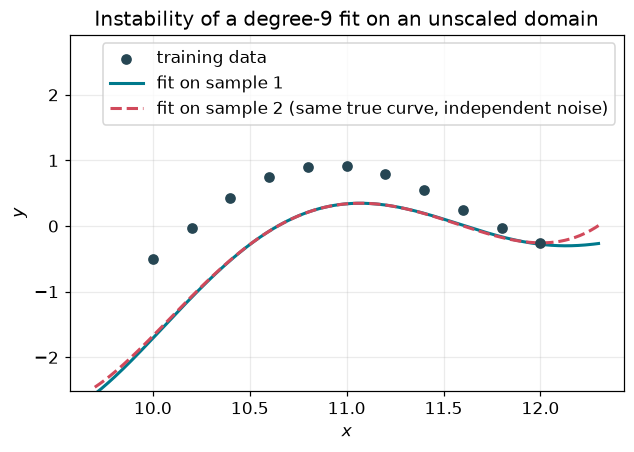

max curve difference relative to the data range: 19.3%


In [4]:
def condition_number(x, degree):
    Z = design_matrix(x, degree)
    return np.linalg.cond(Z.T @ Z)


ill_cond_rng = np.random.default_rng(101)  # a dedicated, fixed seed for a reproducible demo
degree = 9
x_narrow = np.linspace(10.0, 12.0, 11)  # unscaled, narrow domain, near-interpolation budget
true_curve = lambda x: np.sin(2.0 * (x - 10.0)) + 0.5 * (x - 11.0)
y_narrow = true_curve(x_narrow) + ill_cond_rng.normal(scale=0.01, size=x_narrow.size)

kappa = condition_number(x_narrow, degree)
print(f"condition number of Z^T Z (degree={degree}, unscaled domain): {kappa:.3e}")
assert kappa > 1e10, "this domain/degree combination should be badly ill-conditioned"

y_perturbed = true_curve(x_narrow) + ill_cond_rng.normal(scale=0.01, size=x_narrow.size)  # an independent noisy resample
w1 = normal_equations_fit(x_narrow, y_narrow, degree)
w2 = normal_equations_fit(x_narrow, y_perturbed, degree)

x_plot = np.linspace(x_narrow.min() - 0.3, x_narrow.max() + 0.3, 300)  # a touch beyond the sampled range
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(x_narrow, y_narrow, color=COLORS["data"], zorder=3, label="training data")
ax.plot(x_plot, design_matrix(x_plot, degree) @ w1, color=COLORS["fit"], lw=2, label="fit on sample 1")
ax.plot(x_plot, design_matrix(x_plot, degree) @ w2, color=COLORS["perturbed"], lw=2, ls="--",
        label="fit on sample 2 (same true curve, independent noise)")
ax.set(xlabel="$x$", ylabel="$y$", ylim=(y_narrow.min() - 2, y_narrow.max() + 2),
       title=f"Instability of a degree-{degree} fit on an unscaled domain")
ax.legend(); plt.show()

curve1 = design_matrix(x_plot, degree) @ w1
curve2 = design_matrix(x_plot, degree) @ w2
divergence_ratio = np.max(np.abs(curve1 - curve2)) / (y_narrow.max() - y_narrow.min())
print(f"max curve difference relative to the data range: {divergence_ratio:.1%}")
assert divergence_ratio > 0.1, "an ill-conditioned fit should diverge sharply just beyond the sampled range"

Two data sets drawn from the *same* underlying function, differing only by
independent measurement noise, produced fitted curves that agree closely
within the sampled range but fly apart just beyond it -- exactly the
instability shown in the lecture's `ls_no_reg` example.

---
## 3. Fixing it: ridge regression

Adding $\lambda\|\mathbf w\|^2$ to the least-squares objective gives the
regularized normal equations
$$\mathbf w_{\text{ridge}}=\left(\mathbf Z^\mathsf T\mathbf Z+\lambda\mathbf I\right)^{-1}\mathbf Z^\mathsf T\mathbf y.$$
Adding $\lambda\mathbf I$ raises every eigenvalue of $\mathbf Z^\mathsf T\mathbf Z$ by
$\lambda$, directly improving the condition number -- at the cost of biasing
$\mathbf w$ toward $\mathbf 0$.

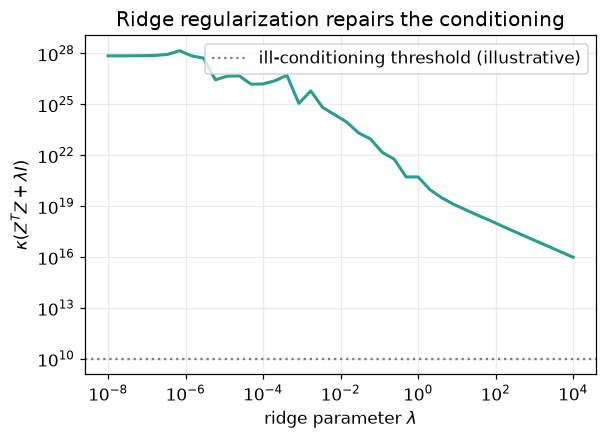

In [5]:
def ridge_fit(x, y, degree, lam):
    Z = design_matrix(x, degree)
    return np.linalg.inv(Z.T @ Z + lam * np.eye(degree + 1)) @ Z.T @ y


def ridge_condition_number(x, degree, lam):
    Z = design_matrix(x, degree)
    return np.linalg.cond(Z.T @ Z + lam * np.eye(degree + 1))


lambdas = np.logspace(-8, 4, 40)
kappas = [ridge_condition_number(x_narrow, degree, lam) for lam in lambdas]

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(lambdas, kappas, color=COLORS["ridge"], lw=2)
ax.axhline(1e10, color="gray", ls=":", label="ill-conditioning threshold (illustrative)")
ax.set(xlabel=r"ridge parameter $\lambda$", ylabel=r"$\kappa(Z^T Z+\lambda I)$",
       title="Ridge regularization repairs the conditioning")
ax.legend(); plt.show()

assert kappas[-1] < kappas[0], "conditioning should improve as lambda grows"

In [ ]:
def plot_ridge_stability(lam=1.0):
    w1 = ridge_fit(x_narrow, y_narrow, degree, lam)
    w2 = ridge_fit(x_narrow, y_perturbed, degree, lam)
    fig, ax = plt.subplots(figsize=(6.5, 4.2))
    ax.scatter(x_narrow, y_narrow, color=COLORS["data"], zorder=3, label="training data")
    ax.plot(x_plot, design_matrix(x_plot, degree) @ w1, color=COLORS["fit"], lw=2, label="fit on sample 1")
    ax.plot(x_plot, design_matrix(x_plot, degree) @ w2, color=COLORS["perturbed"], lw=2, ls="--",
            label="fit on sample 2 (same true curve)")
    ax.set(xlabel="$x$", ylabel="$y$", ylim=(y_narrow.min() - 2, y_narrow.max() + 2),
           title=f"Same degree-{degree} fit with ridge $\\lambda$={lam:g}")
    ax.legend(); plt.show()
    relative_change = np.linalg.norm(w2 - w1) / np.linalg.norm(w1)
    print(f"relative change in fitted coefficients: {relative_change:.2%}")


if WIDGETS_AVAILABLE:
    display(widgets.interactive(
        plot_ridge_stability,
        lam=widgets.FloatLogSlider(value=1.0, base=10, min=-6, max=3, step=0.5, description="lambda"),
    ))
else:
    plot_ridge_stability(lam=1.0)

interactive(children=(FloatLogSlider(value=1.0, description='lambda', max=3.0, min=-6.0, step=0.5), Output()),…

Drag $\lambda$ up from a tiny value: the two curves (sample 1 vs. sample 2)
converge almost on top of each other well before $\lambda$ is large enough to
visibly distort the fit -- exactly the trade-off from the slide: conditioning
improves quickly, while bias only becomes visible for much larger $\lambda$.

> **Predict:** does test-set RMSE vs. $\lambda$ look U-shaped, like it did vs.
> polynomial degree in the DOE notebook?

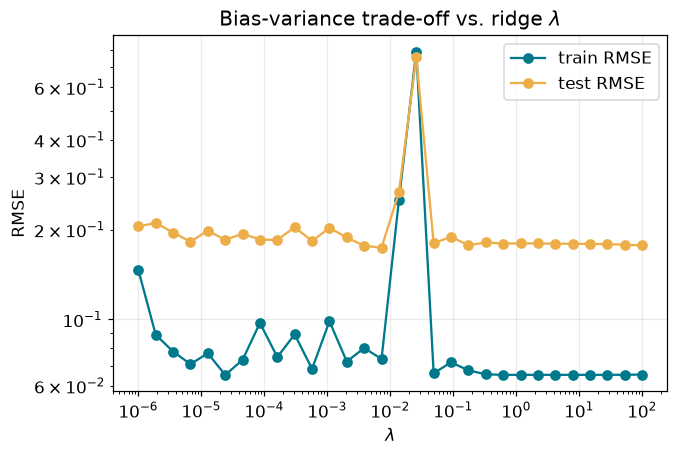

best lambda by held-out RMSE: 0.00728


In [7]:
def train_test_rmse_vs_lambda(x_train, y_train, x_test, y_test, degree, lambdas):
    train_rmses, test_rmses = [], []
    for lam in lambdas:
        w = ridge_fit(x_train, y_train, degree, lam)
        train_rmses.append(np.sqrt(np.mean((design_matrix(x_train, degree) @ w - y_train) ** 2)))
        test_rmses.append(np.sqrt(np.mean((design_matrix(x_test, degree) @ w - y_test) ** 2)))
    return np.array(train_rmses), np.array(test_rmses)


x_train_wide = rng.uniform(10.0, 12.0, size=14)
y_true_wide = np.sin(2.0 * (x_train_wide - 10.0)) + 0.5 * (x_train_wide - 11.0)
y_train_wide = y_true_wide + rng.normal(scale=0.15, size=x_train_wide.size)
x_test_wide = rng.uniform(10.0, 12.0, size=200)
y_test_wide = np.sin(2.0 * (x_test_wide - 10.0)) + 0.5 * (x_test_wide - 11.0) + rng.normal(scale=0.15, size=200)

lambdas_sweep = np.logspace(-6, 2, 30)
train_rmses, test_rmses = train_test_rmse_vs_lambda(x_train_wide, y_train_wide, x_test_wide, y_test_wide,
                                                     degree=10, lambdas=lambdas_sweep)

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.loglog(lambdas_sweep, train_rmses, "o-", color=COLORS["fit"], label="train RMSE")
ax.loglog(lambdas_sweep, test_rmses, "o-", color=COLORS["test"], label="test RMSE")
ax.set(xlabel=r"$\lambda$", ylabel="RMSE", title="Bias-variance trade-off vs. ridge $\\lambda$")
ax.legend(); plt.show()

best_lambda = lambdas_sweep[np.argmin(test_rmses)]
print(f"best lambda by held-out RMSE: {best_lambda:.3g}")

---
## 4. The free fix: variable scaling

Scaling $x$ to $[0,1]$ does not change the *model*, only the *arithmetic* used
to fit it -- so it repairs conditioning at zero cost in accuracy.

condition number, unscaled domain [10,12]: 7.194e+27
condition number, scaled to [0,1]:         8.254e+13


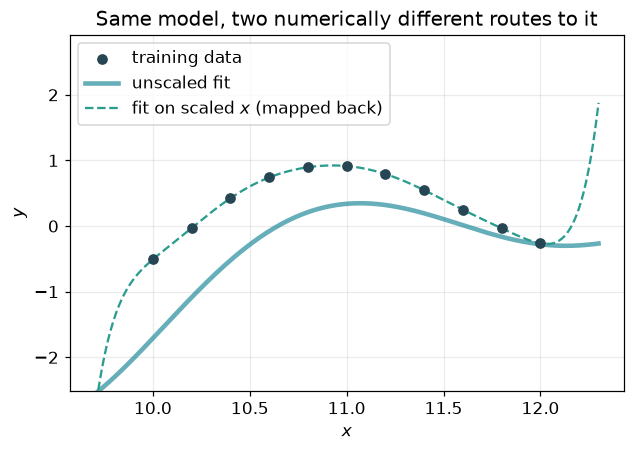

In [8]:
def min_max_scale(x, lower=None, upper=None):
    lower = x.min() if lower is None else lower
    upper = x.max() if upper is None else upper
    return (x - lower) / (upper - lower)


kappa_unscaled = condition_number(x_narrow, degree)
x_scaled = min_max_scale(x_narrow)
kappa_scaled = condition_number(x_scaled, degree)
print(f"condition number, unscaled domain [10,12]: {kappa_unscaled:.3e}")
print(f"condition number, scaled to [0,1]:         {kappa_scaled:.3e}")
assert kappa_scaled < kappa_unscaled / 1e3, "scaling should improve the condition number by orders of magnitude"

w_unscaled = normal_equations_fit(x_narrow, y_narrow, degree)
w_scaled = normal_equations_fit(x_scaled, y_narrow, degree)

x_plot_scaled = min_max_scale(x_plot, x_narrow.min(), x_narrow.max())
fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.scatter(x_narrow, y_narrow, color=COLORS["data"], zorder=3, label="training data")
ax.plot(x_plot, design_matrix(x_plot, degree) @ w_unscaled, color=COLORS["fit"], lw=3, alpha=0.6, label="unscaled fit")
ax.plot(x_plot, design_matrix(x_plot_scaled, degree) @ w_scaled, color=COLORS["ridge"], lw=1.5, ls="--",
        label="fit on scaled $x$ (mapped back)")
ax.set(xlabel="$x$", ylabel="$y$", ylim=(y_narrow.min() - 2, y_narrow.max() + 2),
       title="Same model, two numerically different routes to it")
ax.legend(); plt.show()

The two curves are visually identical (up to floating-point noise) -- scaling
changed *how reliably* we could compute the coefficients, not the model
itself.

## Takeaways

1. The normal equations reproduce `numpy.linalg.lstsq` exactly for a
   well-posed problem.
2. Ill-conditioning comes from collinear/badly scaled design-matrix columns
   (e.g. a high-degree polynomial on a narrow, unscaled domain), not from
   having "too much data."
3. Ridge regression ($\mathbf Z^\mathsf T\mathbf Z+\lambda\mathbf I$) stabilizes the
   fit; $\lambda$ trades bias for variance and should be chosen by held-out
   error, not training error.
4. Scaling variables to $[0,1]$ fixes conditioning for free, with no change to
   the fitted model.

## Classroom exercises

1. Increase the polynomial degree in Section 2 to 12. How much worse does the
   condition number get?
2. In Section 3, find (by eye) the smallest $\lambda$ that keeps the relative
   coefficient change below 1%.
3. Combine scaling *and* ridge: does scaling reduce how much regularization is
   needed to stabilize the degree-8 fit?